In [1]:
import numpy as np
from pytdigest import TDigest        # explicit package
# check details here: https://raw.githubusercontent.com/protivinsky/pytdigest/main/pytdigest/pytdigest.py

def create_digest(data, weights=None, compression=300):
    """Create a t-digest object for given data and compression parameter"""
    data = np.asarray(data)
    #if weights is None:
    #    weights = np.ones_like(data)
    td = TDigest.compute(data, weights, compression=compression)  # vectorised C loop
    return td

def get_quantiles_from_tdigest(td,
                               quantile_list=
                                  ( [.0000001, .000001, .00001, .0001, .001, .01]
                                   + list(np.arange(.1, .95, .05))
                                   + [.99, .999, .9999, .99999, .999999, .9999999])
                               ):
    """Create quantiles from a given data->t-digest and specified quantile values."""
    #td = create_digest(data)
    #print(td)
    #td = digest
    quantiles = [td.inverse_cdf(q) for q in quantile_list]
    return  quantiles, quantile_list

if __name__ == "__main__":

    N = 10_000_000
    data = np.random.uniform(0, 100, N)

    td = create_digest(data)
    print(type(td))
   # print(end - start)

    #qs = [.0000001, .000001, .00001, .0001, .001, .01] \
    # + list(np.arange(.1, .95, .05)) \
    # + [.99, .999, .9999, .99999, .999999, .9999999]

    print(get_quantiles_from_tdigest(td))

    #digest_dict = td.to_dict()
    #print(digest_dict)

<class 'pytdigest.pytdigest.TDigest'>
([1.9426391612009652e-05, 0.00015664511849681576, 0.0010411806604693967, 0.010384258748371365, 0.10113006907545258, 1.009891631587841, 10.135852663488544, 15.080559657857462, 20.26061722939882, 25.015023049092196, 29.96928618829545, 35.19525401859297, 39.97457874865998, 45.071480129850286, 50.22322337553292, 55.00210476492352, 59.867014673099696, 64.82215859672111, 69.83733880320536, 74.95605071664924, 79.9521978131003, 84.95092029657691, 89.96123621717547, 98.99877611286401, 99.90066971173835, 99.98968287011144, 99.99891424048778, 99.99986766377745, 99.99999149512811], [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15000000000000002, 0.20000000000000004, 0.25000000000000006, 0.30000000000000004, 0.3500000000000001, 0.40000000000000013, 0.45000000000000007, 0.5000000000000001, 0.5500000000000002, 0.6000000000000002, 0.6500000000000001, 0.7000000000000002, 0.7500000000000002, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.99, 0.999

In [3]:
N = 10_000_000

data_uniform = np.random.uniform(0, 100, N)   # N samples in [0, 100)
data_normal  = np.random.normal(0, 1, N)      # mean=0, std=1, N samples

In [8]:
td = create_digest(data_normal)

quantile_values, quantile_list = get_quantiles_from_tdigest(td)


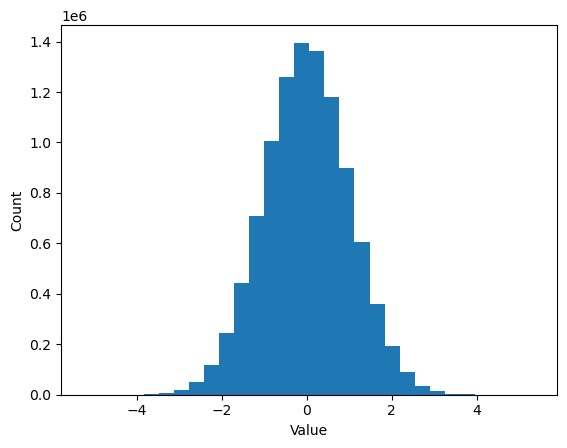

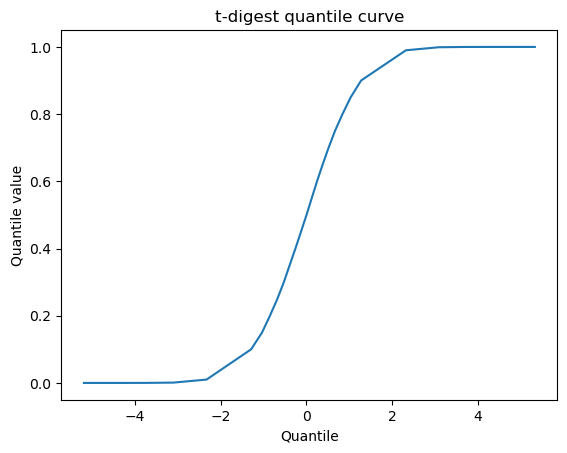

In [11]:
import matplotlib.pyplot as plt

# histogram of data_uniform
plt.figure()
plt.hist(data_normal, bins=30)
plt.xlabel("Value")
plt.ylabel("Count")
#plt.title("Histogram of data_uniform")
plt.show()

# quantile_values (y) vs quantile_list (x)
plt.figure()
plt.plot(quantile_values, quantile_list)
plt.xlabel("Quantile")
plt.ylabel("Quantile value")
plt.title("t-digest quantile curve")
plt.show()